In [193]:
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import r2_score, accuracy_score,f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

In [194]:
data_path = "fifa_world_cup_2026_player_performance.csv"

df = pd.read_csv(data_path)

df.head(12)

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7
5,P00072,Dani Gavi,21,Spanish,Spain,20,Midfielder,181,78,Right,...,17.0,65.4,85.8,91.1,48.2,1,2,332,0,6.7
6,P00058,Rodri Laporte,27,Spanish,Spain,6,Defender,188,80,Right,...,6.4,48.7,15.3,61.8,55.1,0,1,264,0,7.0
7,P00078,Ansu Fati,27,Spanish,Spain,26,Forward,182,72,Right,...,2.4,48.2,35.6,60.9,60.4,2,1,191,0,6.8
8,P00056,Pedro Torres,24,Spanish,Spain,4,Defender,176,78,Left,...,6.4,52.7,31.3,68.3,59.2,0,0,324,0,6.7
9,P00074,Gavi Le Normand,25,Spanish,Spain,22,Forward,172,70,Right,...,11.1,99.0,68.8,92.1,47.6,1,3,547,0,5.7


In [195]:
# Checking missing values or null data

print(f"Missing Values : {df.isnull().sum().max()}")

Missing Values : 0


In [196]:
# Reading information about data

print("Reading the data types : \n", df.info())


<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [197]:
# Checking unique feature type object

cols = df.select_dtypes(include=['str', 'object'])

for i, col_name in enumerate(cols):
    unique_count = df[col_name].unique().sum()
    
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

Index 0: 'player_id' has P00055P00070P00066P00073P00059P00072P00058P00078P00056P00074P00069P00071P00076P00067P00057P00062P00077P00064P00061P00068P00060P00075P00063P00065P00053P00054P01225P01241P01243P01240P01228P01239P01247P01229P01244P01233P01238P01246P01226P01227P01237P01234P01235P01236P01245P01232P01248P01231P01230P01242P01224P01223P00626P00635P00650P00629P00638P00633P00636P00632P00639P00630P00642P00648P00646P00647P00634P00637P00628P00641P00631P00640P00644P00649P00643P00645P00625P00627P00133P00141P00147P00145P00140P00136P00153P00135P00154P00144P00156P00138P00137P00146P00142P00149P00134P00155P00152P00150P00148P00139P00151P00143P00131P00132P01041P01054P01059P01048P01063P01045P01062P01058P01050P01065P01066P01064P01047P01057P01056P01060P01049P01055P01061P01053P01044P01046P01051P01052P01042P01043P01017P01031P01036P01030P01023P01037P01019P01034P01038P01039P01033P01026P01020P01022P01029P01025P01021P01024P01040P01035P01032P01028P01027P01018P01016P01015P01172P01196P01193P01178P01186P01183P01

In [198]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_3483/1539823980.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position', y='player_rating',
/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_3483/1539823980.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='position', y='age',


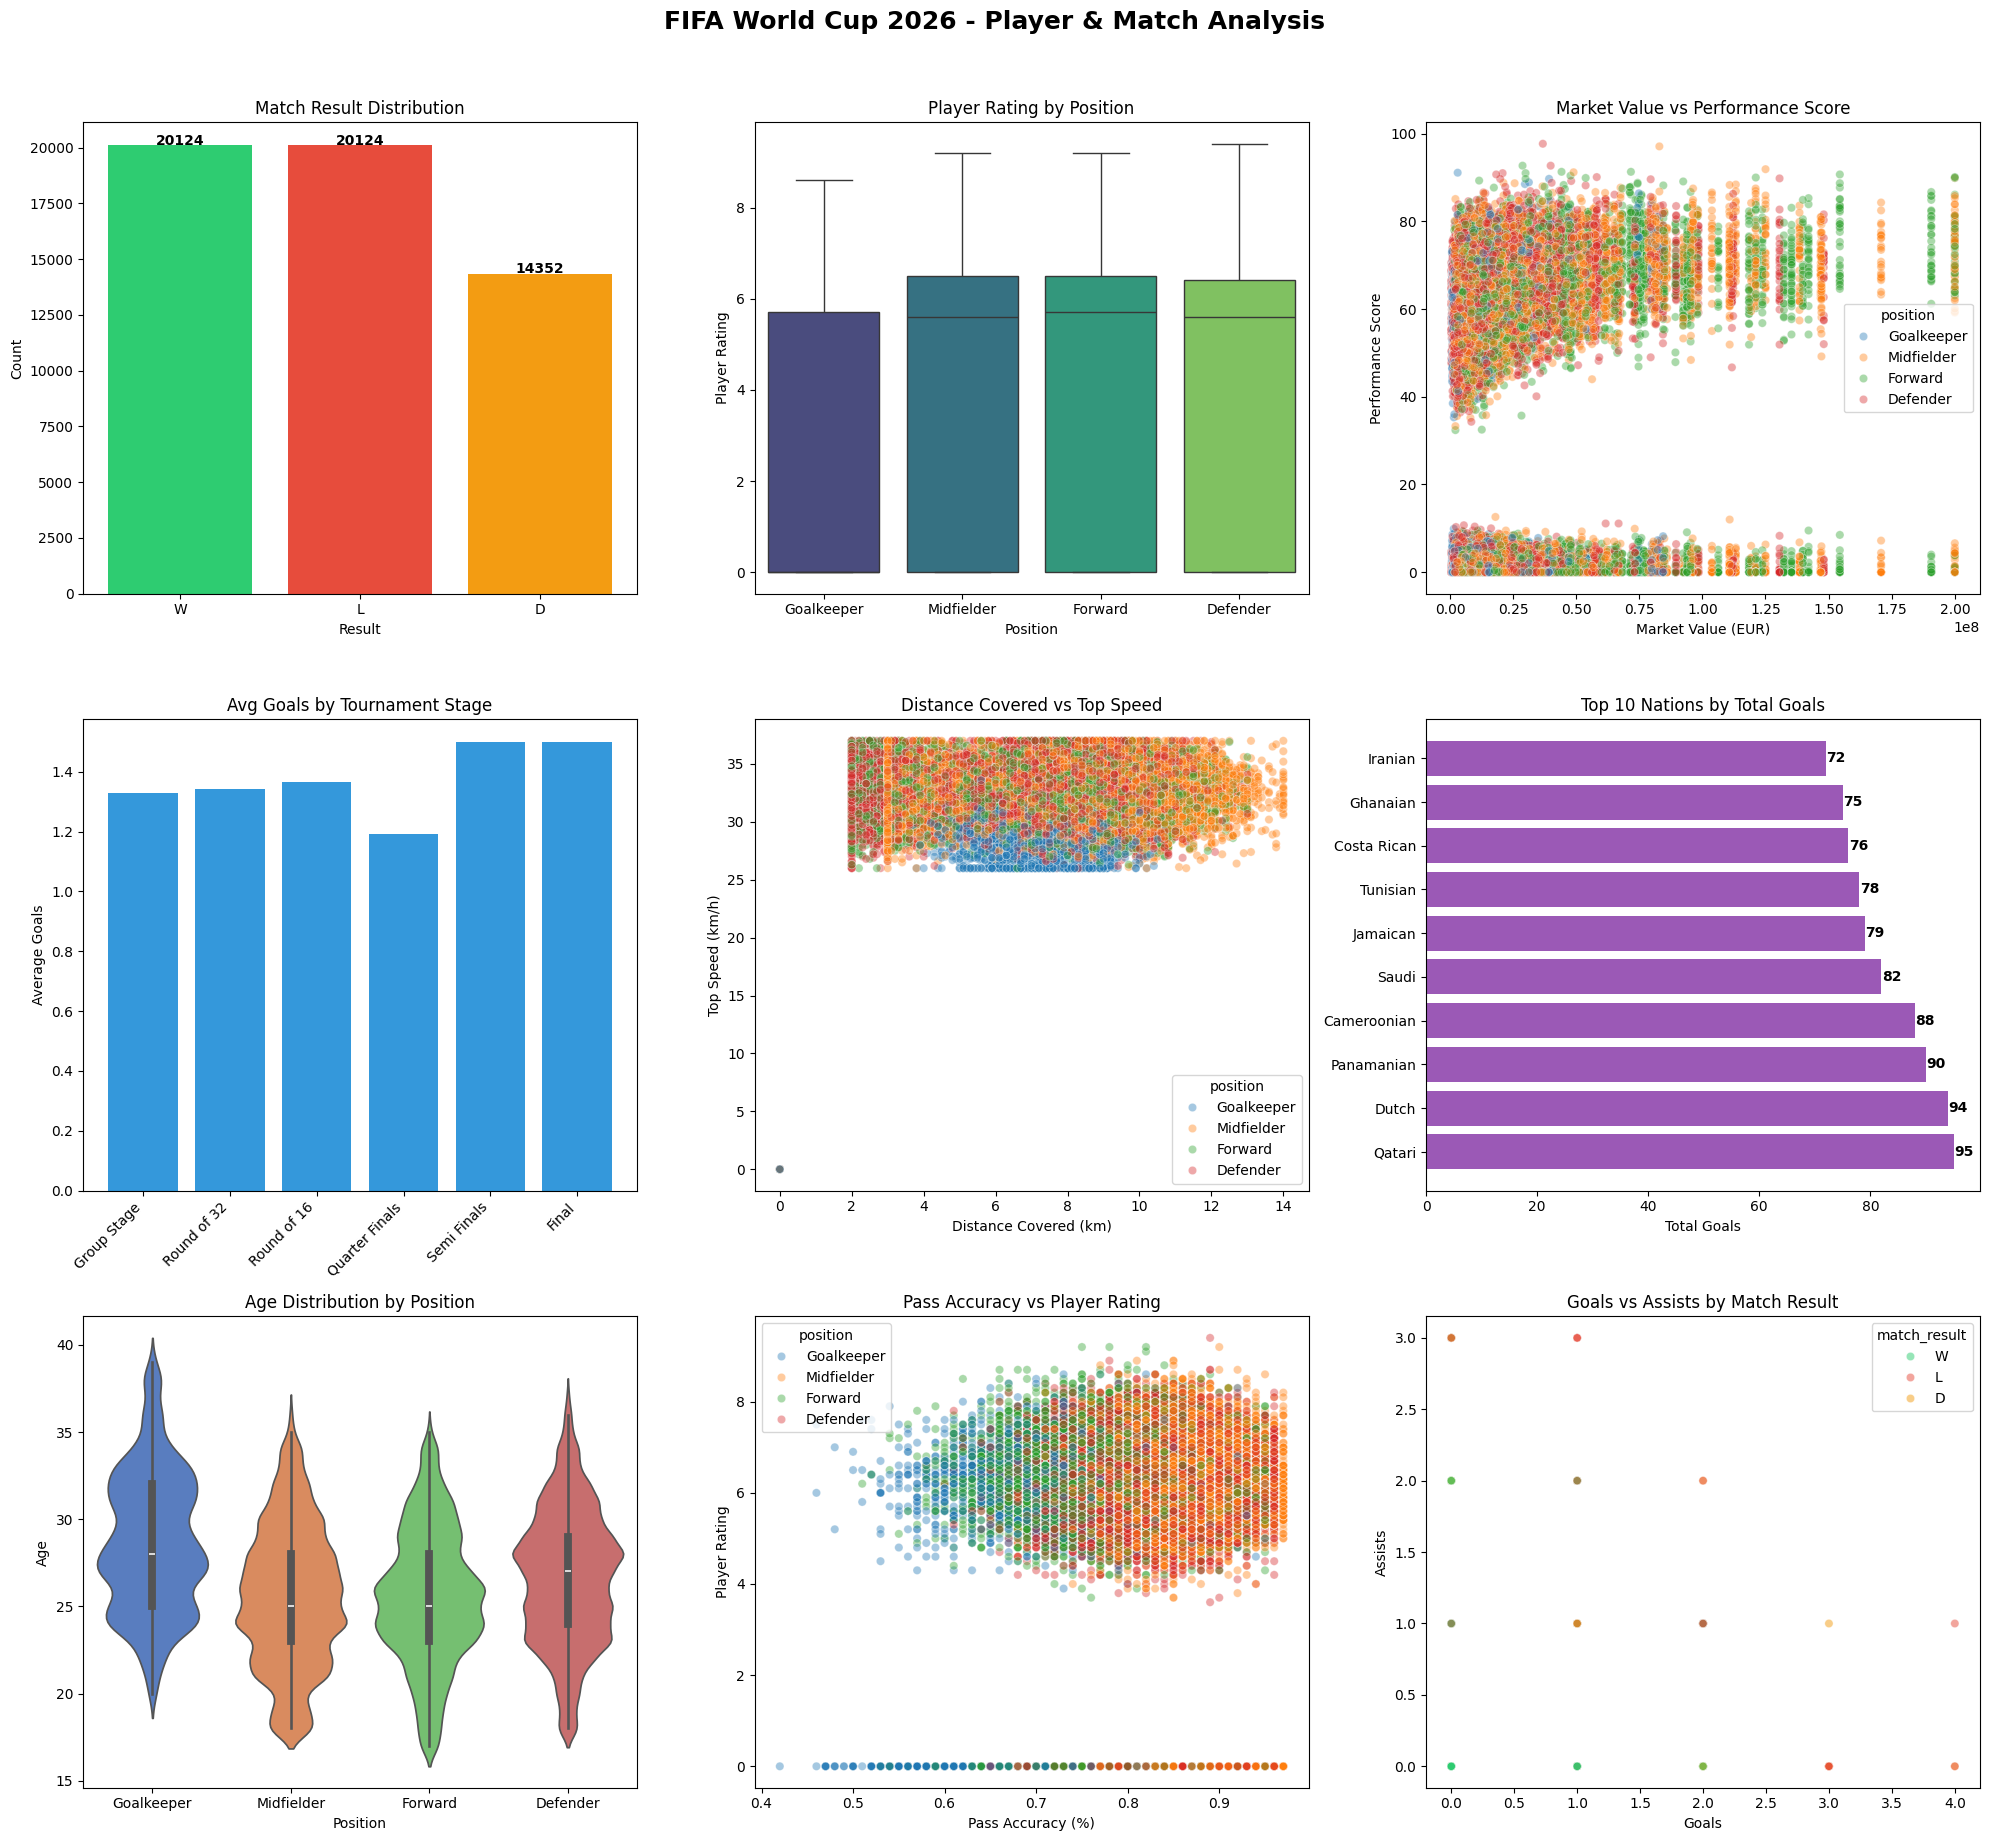

In [199]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('FIFA World Cup 2026 - Player & Match Analysis', 
             fontsize=18, fontweight='bold', y=1.02)

# 1. Match Result Distribution
match_colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}
match_counts = df['match_result'].value_counts()
axes[0, 0].bar(match_counts.index, match_counts.values, 
               color=[match_colors[x] for x in match_counts.index])
axes[0, 0].set_title('Match Result Distribution')
axes[0, 0].set_xlabel('Result')
axes[0, 0].set_ylabel('Count')
for i, (idx, val) in enumerate(match_counts.items()):
    axes[0, 0].text(i, val + 10, str(val), ha='center', fontweight='bold')

# 2. Player Rating by Position
sns.boxplot(data=df, x='position', y='player_rating',
            palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Player Rating by Position')
axes[0, 1].set_xlabel('Position')
axes[0, 1].set_ylabel('Player Rating')

# 3. Market Value vs Performance Score
sns.scatterplot(data=df, x='market_value_eur', y='performance_score',
                hue='position', alpha=0.4, ax=axes[0, 2])
axes[0, 2].set_title('Market Value vs Performance Score')
axes[0, 2].set_xlabel('Market Value (EUR)')
axes[0, 2].set_ylabel('Performance Score')

# 4. Goals by Tournament Stage
stage_order = ['Group Stage', 'Round of 32', 'Round of 16', 
               'Quarter Finals', 'Semi Finals', 'Final']
stage_goals = df.groupby('tournament_stage')['goals_team'].mean().reindex(stage_order)
axes[1, 0].bar(range(len(stage_goals)), stage_goals.values, color='#3498db')
axes[1, 0].set_xticks(range(len(stage_goals)))
axes[1, 0].set_xticklabels(stage_order, rotation=45, ha='right')
axes[1, 0].set_title('Avg Goals by Tournament Stage')
axes[1, 0].set_ylabel('Average Goals')

# 5. Top Speed vs Distance Covered
sns.scatterplot(data=df, x='distance_covered_km', y='top_speed_kmh',
                hue='position', alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Distance Covered vs Top Speed')
axes[1, 1].set_xlabel('Distance Covered (km)')
axes[1, 1].set_ylabel('Top Speed (km/h)')

# 6. Top 10 Nations by Goals
top_nations = df.groupby('nationality')['goals'].sum().nlargest(10)
axes[1, 2].barh(top_nations.index, top_nations.values, color='#9b59b6')
axes[1, 2].set_title('Top 10 Nations by Total Goals')
axes[1, 2].set_xlabel('Total Goals')
for i, val in enumerate(top_nations.values):
    axes[1, 2].text(val + 0.1, i, str(val), va='center', fontweight='bold')

# 7. Age Distribution by Position
sns.violinplot(data=df, x='position', y='age',
               palette='muted', ax=axes[2, 0])
axes[2, 0].set_title('Age Distribution by Position')
axes[2, 0].set_xlabel('Position')
axes[2, 0].set_ylabel('Age')

# 8. Pass Accuracy vs Player Rating
sns.scatterplot(data=df, x='pass_accuracy', y='player_rating',
                hue='position', alpha=0.4, ax=axes[2, 1])
axes[2, 1].set_title('Pass Accuracy vs Player Rating')
axes[2, 1].set_xlabel('Pass Accuracy (%)')
axes[2, 1].set_ylabel('Player Rating')

# 9. Goals vs Assists (Top Performers)
sns.scatterplot(data=df, x='goals', y='assists',
                hue='match_result', alpha=0.5,
                palette={'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'},
                ax=axes[2, 2])
axes[2, 2].set_title('Goals vs Assists by Match Result')
axes[2, 2].set_xlabel('Goals')
axes[2, 2].set_ylabel('Assists')

plt.tight_layout()
plt.show()

In [200]:
dfe = df.copy()

drop_cols = ['player_id', 'player_name', 'club_name']
dfe = dfe.drop(columns=drop_cols, errors='ignore')

cat_cols = dfe.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = dfe.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols = [c for c in cat_cols if c not in ['match_result', 'match_id', 'team']]
num_cols = [c for c in num_cols if c not in ['match_result', 'goals_team', 'goals_opponent']]

print("Categorical cols:", cat_cols)
print("Numerical cols:", num_cols)

X = dfe[cat_cols + num_cols]
y = dfe['match_result']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

num_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


Categorical cols: ['nationality', 'position', 'preferred_foot', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage']
Numerical cols: ['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rating', 'performance_score', 'offensive_contribution', 'defensive_contribution', 'possession_impact', 'pre

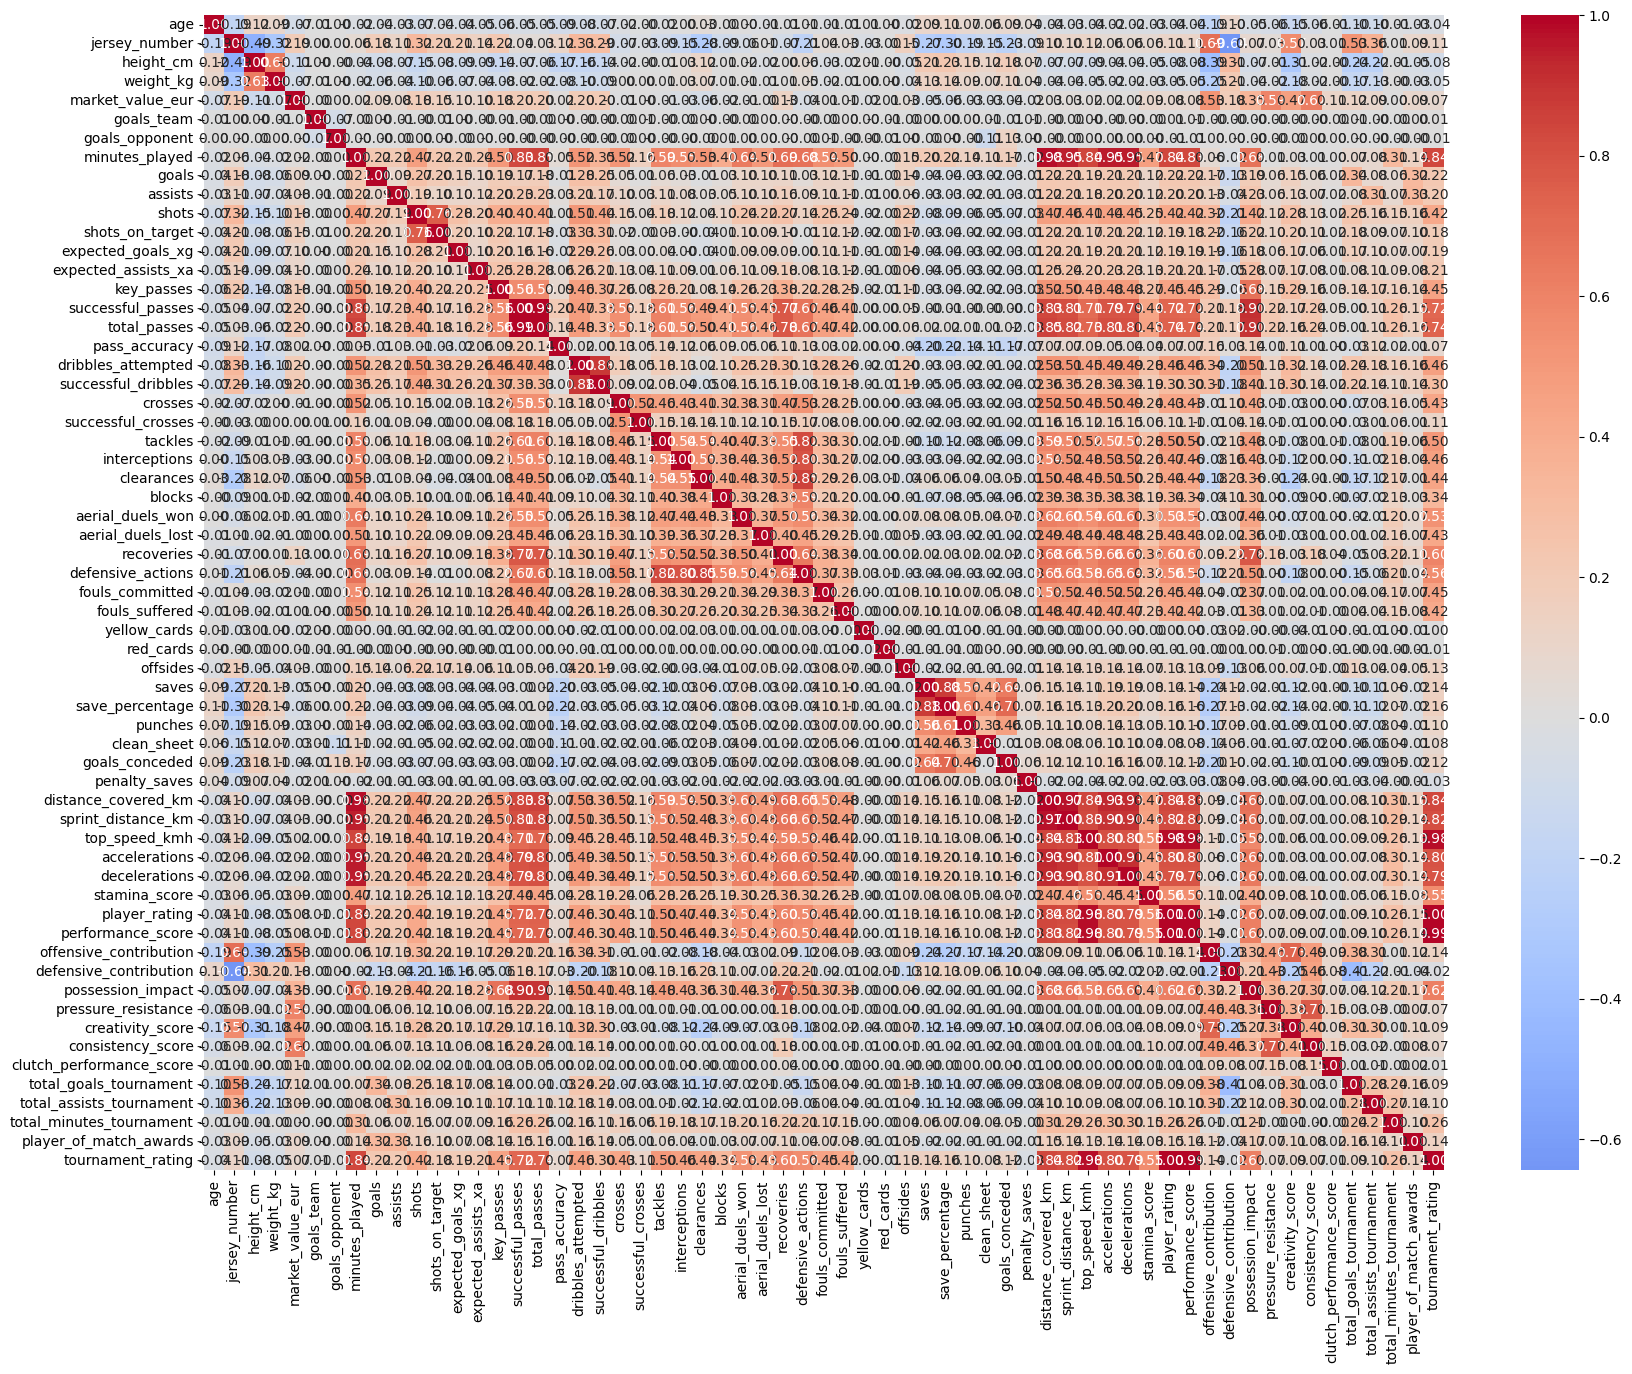

In [203]:
plt.figure(figsize=(20,15))

sns.heatmap(dfe.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0)

plt.show()

Train: 0.7788
Test:  0.7222
              precision    recall  f1-score   support

        Loss       0.61      0.81      0.70      2783
        Draw       0.79      0.68      0.73      4075
         Win       0.76      0.70      0.73      4062

    accuracy                           0.72     10920
   macro avg       0.72      0.73      0.72     10920
weighted avg       0.74      0.72      0.72     10920



<Figure size 1000x400 with 0 Axes>

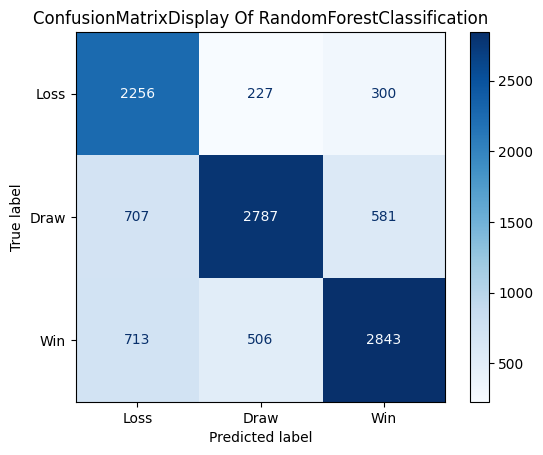


Calculating Learning Curve...


KeyboardInterrupt: 

In [ ]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])

full_pipeline.fit(X_train, y_train)

train_preds = full_pipeline.predict(X_train)
test_preds  = full_pipeline.predict(X_valid)

train_acc = accuracy_score(y_train, train_preds)
test_acc  = accuracy_score(y_valid, test_preds)

print(f"Train: {train_acc:.4f}")
print(f"Test:  {test_acc:.4f}")
print(classification_report(y_valid, test_preds, target_names=['Loss', 'Draw', 'Win']))

cm = confusion_matrix(y_valid, test_preds)

plt.figure(figsize=(10,4)) 

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss", "Draw", "Win"])

disp.plot(cmap=plt.cm.Blues)

plt.title("ConfusionMatrixDisplay Of RandomForestClassification") 
plt.show() 

print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5) # Testing data from 10% -> 100%

if isinstance(X_train, pd.DataFrame):
    X_full = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
    y_full = pd.concat([pd.Series(y_train), pd.Series(y_valid)], axis=0).reset_index(drop=True)
else:
    # Fallback if they are already numpy arrays (and your preprocessor doesn't require strings)
    X_full = np.vstack((X_train, X_valid))
    y_full = np.concatenate((y_train, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=full_pipeline,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

